In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s4e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e4/train.csv
/kaggle/input/competitions/playground-series-s4e4/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


import warnings
warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s4e4/train.csv")
test=pd.read_csv("/kaggle/input/competitions/playground-series-s4e4/test.csv")

In [4]:
print(train.shape)
print(test.shape)

(90615, 10)
(60411, 9)


In [5]:
train.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [6]:
test.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight
0,90615,M,0.645,0.475,0.155,1.2380,0.6185,0.3125,0.3005
1,90616,M,0.580,0.460,0.160,0.9830,0.4785,0.2195,0.2750
2,90617,M,0.560,0.420,0.140,0.8395,0.3525,0.1845,0.2405
3,90618,M,0.570,0.490,0.145,0.8740,0.3525,0.1865,0.2350
4,90619,I,0.415,0.325,0.110,0.3580,0.1575,0.0670,0.1050


In [7]:
train.isnull().sum()

id                0
Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
Rings             0
dtype: int64

In [8]:
df=pd.concat([train,test])

## EDA

In [9]:
df.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11.0
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11.0
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6.0
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10.0
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 151026 entries, 0 to 60410
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              151026 non-null  int64  
 1   Sex             151026 non-null  object 
 2   Length          151026 non-null  float64
 3   Diameter        151026 non-null  float64
 4   Height          151026 non-null  float64
 5   Whole weight    151026 non-null  float64
 6   Whole weight.1  151026 non-null  float64
 7   Whole weight.2  151026 non-null  float64
 8   Shell weight    151026 non-null  float64
 9   Rings           90615 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 12.7+ MB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,151026.0,75512.500000,43597.595215,0.0000,37756.2500,75512.5000,113268.7500,151025.0000
Length,151026.0,0.517230,0.117974,0.0750,0.4450,0.5450,0.6000,0.8150
Diameter,151026.0,0.401792,0.097804,0.0550,0.3450,0.4250,0.4700,0.6500
Height,151026.0,0.135579,0.038075,0.0000,0.1100,0.1400,0.1600,1.1300
Whole weight,151026.0,0.789446,0.457637,0.0020,0.4195,0.7995,1.0680,2.8255
Whole weight.1,151026.0,0.340958,0.204345,0.0010,0.1775,0.3295,0.4635,1.4880
Whole weight.2,151026.0,0.169421,0.100833,0.0005,0.0865,0.1660,0.2325,0.7600
Shell weight,151026.0,0.225989,0.130052,0.0015,0.1200,0.2250,0.3050,1.0050
Rings,90615.0,9.696794,3.176221,1.0000,8.0000,9.0000,11.0000,29.0000


In [12]:
#Correlation by rings
abs(df.corr(numeric_only=True))['Rings'].sort_values(ascending=False) 

Rings             1.000000
Shell weight      0.694766
Height            0.665772
Diameter          0.636832
Length            0.623786
Whole weight      0.617274
Whole weight.2    0.588954
Whole weight.1    0.515067
id                0.000938
Name: Rings, dtype: float64

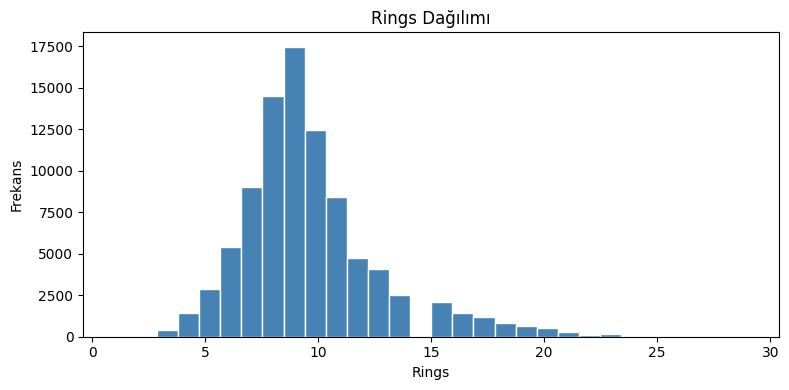

In [13]:
# Rings Distribution
plt.figure(figsize=(8, 4))
plt.hist(df['Rings'].dropna(), bins=30, color='steelblue', edgecolor='white')
plt.title('Rings Dağılımı')
plt.xlabel('Rings')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

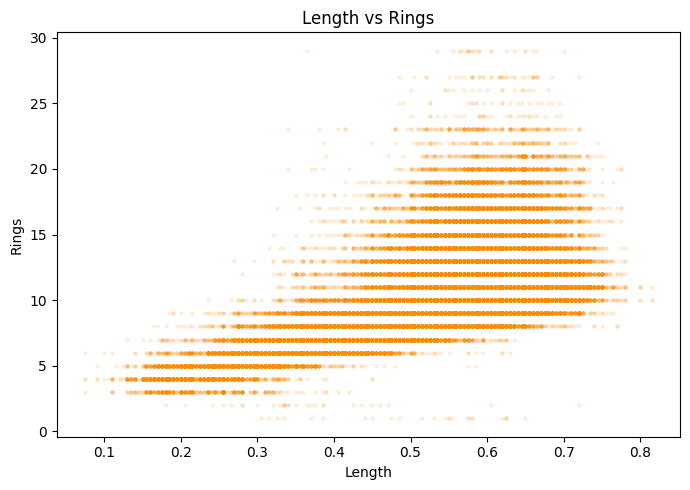

In [14]:
# Length vs Rings Scatter
plt.figure(figsize=(7, 5))
plt.scatter(df['Length'], df['Rings'], alpha=0.1, s=5, color='darkorange')
plt.title('Length vs Rings')
plt.xlabel('Length')
plt.ylabel('Rings')
plt.tight_layout()
plt.show()

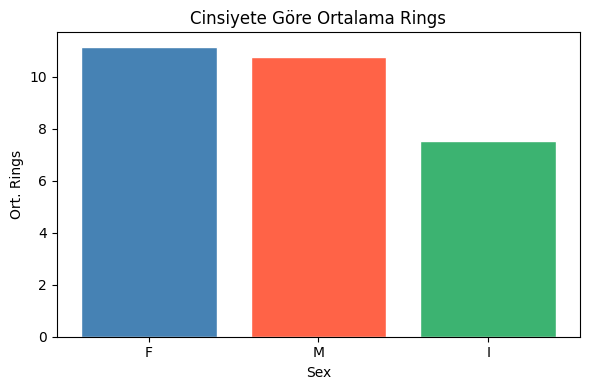

In [15]:
sex_mean = df.groupby('Sex')['Rings'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(sex_mean.index, sex_mean.values, color=['steelblue', 'tomato', 'mediumseagreen'], edgecolor='white')
plt.title('Cinsiyete Göre Ortalama Rings')
plt.xlabel('Sex')
plt.ylabel('Ort. Rings')
plt.tight_layout()
plt.show()

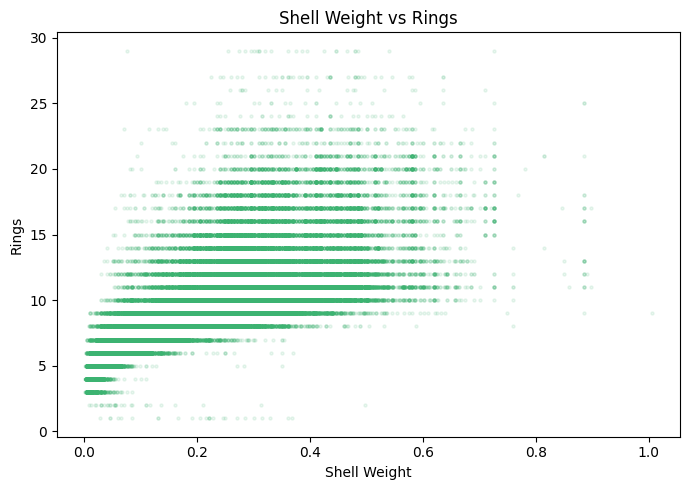

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Shell weight'], df['Rings'], alpha=0.1, s=5, color='mediumseagreen')
plt.title('Shell Weight vs Rings')
plt.xlabel('Shell Weight')
plt.ylabel('Rings')
plt.tight_layout()
plt.show()

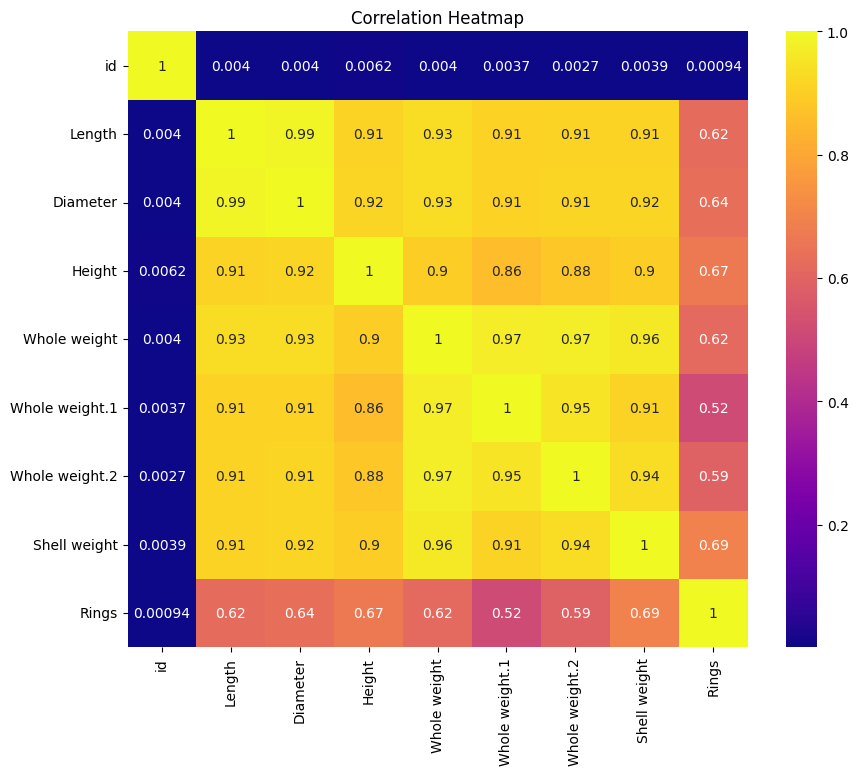

In [17]:
# Corelation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='plasma')
plt.title('Correlation Heatmap')
plt.show()

## Feature Engineering

In [18]:
# Sex
sex_map = {'M': 0, 'F': 1, 'I': 2}
df['Sex'] = df['Sex'].map(sex_map)

In [19]:
# Hacim Tahmini (uzunluk × çap × yükseklik) Kabuklu hayvanın fiziksel hacmi yaşla doğrudan ilişkili
df['Volume'] = df['Length'] * df['Diameter'] * df['Height']

# Et Ağırlığı (toplam - kabuk) İç doku ağırlığı yaşı yansıtır
df['Meat_weight'] = df['Whole weight'] - df['Shell weight']

# Kabuk Oranı Yaşlı hayvanlarda kabuk oranı artar
df['Shell_ratio'] = df['Shell weight'] / (df['Whole weight'] + 1)

# Yoğunluk (ağırlık / hacim)
df['Density'] = df['Whole weight'] / (df['Volume'] + 1)

In [20]:
#Correlation by rings
abs(df.corr(numeric_only=True))['Rings'].sort_values(ascending=False) 

Rings             1.000000
Shell_ratio       0.735211
Shell weight      0.694766
Height            0.665772
Diameter          0.636832
Volume            0.624044
Length            0.623786
Density           0.620717
Whole weight      0.617274
Whole weight.2    0.588954
Meat_weight       0.575133
Whole weight.1    0.515067
Sex               0.431258
id                0.000938
Name: Rings, dtype: float64

## Train Test Split

In [21]:
features = [
    'Shell weight',            
    'Height',                  
    'Diameter',               
    'Volume',                  
    'Length',                  
    'Whole weight',           
    'Whole weight.2',         
    'Meat_weight',             
    'Whole weight.1',          
    'Sex',                 
]

#Train / Test
train = df[df['Rings'].notna()].copy()
test  = df[df['Rings'].isna()].copy()

x = train[features]
y = train['Rings']
x_final_test = test[features]

In [22]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Shell weight    90615 non-null  float64
 1   Height          90615 non-null  float64
 2   Diameter        90615 non-null  float64
 3   Volume          90615 non-null  float64
 4   Length          90615 non-null  float64
 5   Whole weight    90615 non-null  float64
 6   Whole weight.2  90615 non-null  float64
 7   Meat_weight     90615 non-null  float64
 8   Whole weight.1  90615 non-null  float64
 9   Sex             90615 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 7.6 MB


## Model Training

In [23]:
def algo_test(x, y):
    models = {
        'Ridge'           : Ridge(),
        'Decision Tree'   : DecisionTreeRegressor(random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
        'XGBoost'         : XGBRegressor(n_jobs=-1, random_state=42, verbosity=0),
        'LightGBM'        : LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1),
        'KNeighbors'      : KNeighborsRegressor(n_jobs=-1),
    }

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    results = []
    for name, model in models.items():
        model.fit(x_train, y_train)
        p = model.predict(x_test)
        results.append({
            'Model': name,
            'R²'   : round(r2_score(y_test, p), 4),
            'RMSE' : round(mean_squared_error(y_test, p) ** 0.5, 4),
            'MAE'  : round(mean_absolute_error(y_test, p), 4),
        })

    return pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)

In [24]:
algo_test(x, y)

,Model,R²,RMSE,MAE
0,LightGBM,0.6583,1.8735,1.2612
1,XGBoost,0.6546,1.8836,1.2665
2,Gradient Boosting,0.6417,1.9185,1.2979
3,Ridge,0.6061,2.0116,1.3817
4,KNeighbors,0.6011,2.0242,1.3620
5,Decision Tree,0.3010,2.6797,1.7537


In [25]:
best_model = LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1)
best_model.fit(x, y)

prediction = best_model.predict(x_final_test)

In [26]:
submission = pd.DataFrame({'id': test['id'], 'Rings': prediction})

In [27]:
submission.head()

,id,Rings
0,90615,9.698729
1,90616,9.682660
2,90617,10.291340
3,90618,10.310337
4,90619,7.553134


In [28]:
submission.to_csv('submission.csv', index=False)